In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
df=pd.read_excel('k-means.xlsx')

In [3]:
df

,Name,Age,Income
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


In [4]:
df.shape

(22, 3)

Text(0, 0.5, 'Income')

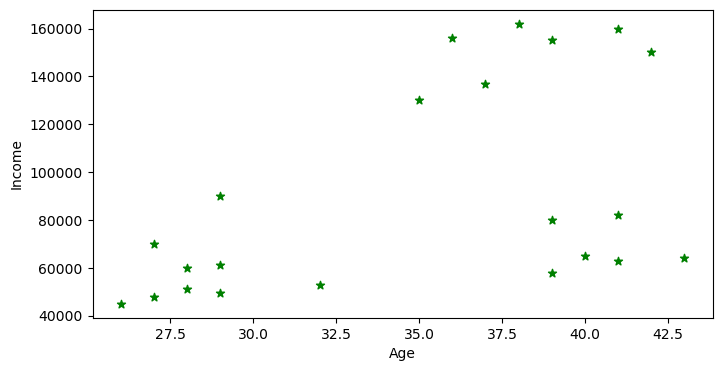

In [5]:
plt.figure(figsize=(8,4))
plt.scatter(df.Age,df.Income,color='Green',marker='*')
plt.xlabel('Age')
plt.ylabel('Income')

In [6]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=3)

In [7]:
y_pred=model.fit_predict(df[['Age','Income']])

  File "C:\Users\Palwinder Singh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Palwinder Singh\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Palwinder Singh\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Palwinder Singh\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [8]:
y_pred

array([1, 0, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1])

In [9]:
df['Cluster']=y_pred

In [10]:
df

,Name,Age,Income,Cluster
0,Rob,27,70000,1
1,Michael,29,90000,0
2,Mohan,29,61000,1
3,Ismail,28,60000,1
4,Kory,42,150000,2
5,Gautam,39,155000,2
6,David,41,160000,2
7,Andrea,38,162000,2
8,Brad,36,156000,2
9,Angelina,35,130000,2


In [11]:
df1=df[df.Cluster==0]
df2=df[df.Cluster==1]
df3=df[df.Cluster==2]

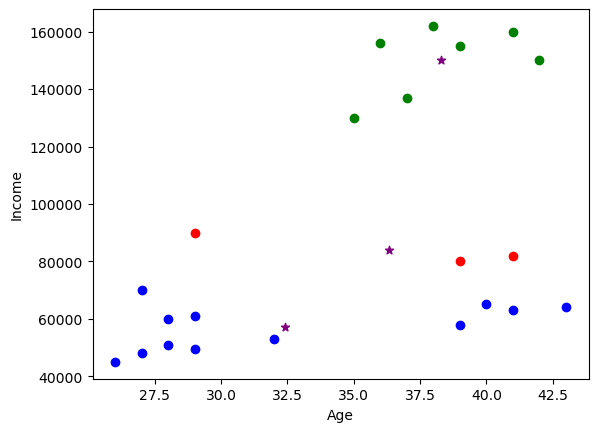

In [12]:
plt.scatter(df1.Age,df1.Income,color='red')
plt.scatter(df2.Age,df2.Income,color='blue')
plt.scatter(df3.Age,df3.Income,color='green')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],color='purple',marker='*',label="Centroid")
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [14]:
sse=[]
k_range=range(1,10)
for k in range(1,10):
    km=KMeans(n_clusters=k)
    km.fit(df[['Age','Income']])
    sse.append(km.inertia_)

In [15]:
sse

[39748148458.54546,
 3318233941.1619043,
 1606229737.6785712,
 1058800432.7238097,
 296500418.0952381,
 242050408.29523814,
 183717018.28333336,
 129716937.61666666,
 134700243.29999998]

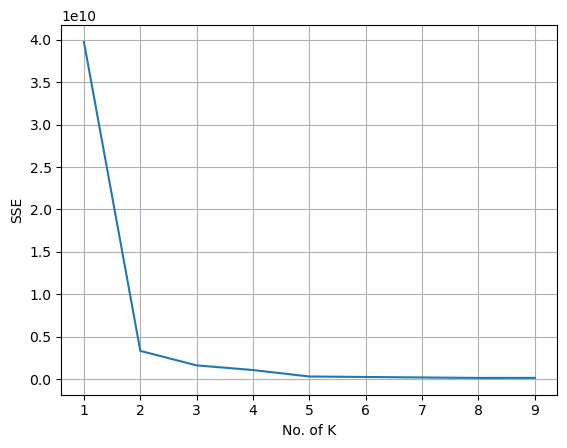

In [16]:
plt.xlabel('No. of K')
plt.ylabel('SSE')
plt.plot(k_range,sse)
plt.grid(True)
plt.show()

In [27]:
from sklearn.metrics import silhouette_score

In [28]:
silhouette_score(df[['Age','Income']],df['Cluster'])

0.8191238627089519

In [17]:
model2=KMeans(n_clusters=2)

In [20]:
y_pred2=model2.fit_predict(df[['Age','Income']])

In [21]:
y_pred2

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [22]:
df['Cluster2']=y_pred2

In [23]:
df

,Name,Age,Income,Cluster,Cluster2
0,Rob,27,70000,1,0
1,Michael,29,90000,0,0
2,Mohan,29,61000,1,0
3,Ismail,28,60000,1,0
4,Kory,42,150000,2,1
5,Gautam,39,155000,2,1
6,David,41,160000,2,1
7,Andrea,38,162000,2,1
8,Brad,36,156000,2,1
9,Angelina,35,130000,2,1


In [25]:
df11=df[df.Cluster2==0]
df21=df[df.Cluster2==1]


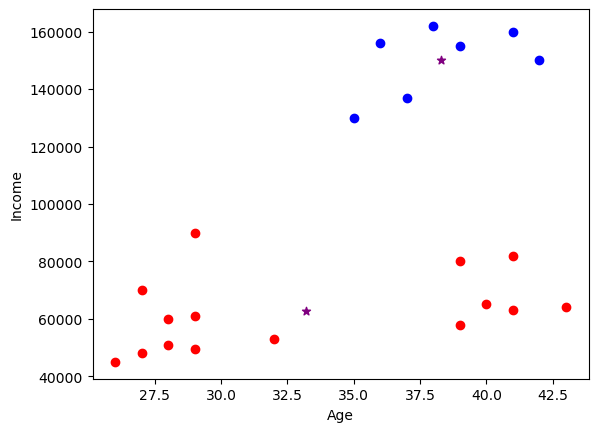

In [26]:
plt.scatter(df11.Age,df11.Income,color='red')
plt.scatter(df21.Age,df21.Income,color='blue')
plt.scatter(model2.cluster_centers_[:,0],model2.cluster_centers_[:,1],color='purple',marker='*',label="Centroid")
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [28]:
silhouette_score(df[['Age','Income']],df['Cluster2'])

0.8191238627089519